In [51]:
%load_ext autoreload
%autoreload 2

import numpy as np
from shapely.geometry import box, mapping, shape, Point
from rasterio.features import shapes as raster_to_shapes
import matplotlib.pyplot as plt
from shapely.geometry import Point
import pystac_client
import planetary_computer as pc
import pandas as pd
import geopandas as gpd
import os
from utils import (
    search_wide_area,
    choose_aoi,
    find_candidates,
    pick_scenes,
    load_scene,
    mask_and_scale,
    valid_observation_count,
    ndvi,
    ndmi,
    evi,
    bsi,
    false_color,
    period_median,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Settings

All the choices of the analysis in one place. Both periods cover the same dry-season months (June to September), so seasonal effects don't get mixed up with the actual change.

In [15]:
REFERENCE_POINT = Point(-63.90, -8.76)   # known deforestation area, Rondônia
SEARCH_RADIUS_DEG = 0.5                  # wide area used only to choose the AOI
AOI_HALF_SIZE_DEG = 0.05                 # AOI of roughly 10 x 10 km

BASELINE_WINDOW = "2018-06-01/2018-09-30"
RECENT_WINDOW = "2023-06-01/2023-09-30"

# SCL classes treated as unusable: no data, saturated, shadow, clouds, cirrus, snow
BAD_SCL_CLASSES = [0, 1, 3, 8, 9, 10, 11]

BANDS = ["B02", "B03", "B04", "B08", "B8A", "B11", "B12", "SCL"]
bands_needed = ["B02", "B03", "B04", "B08", "B8A", "B11", "B12", "SCL"]
# B08 (broad NIR, 10 m) is used for the spectral indices.
# B8A (narrow NIR, 20 m) is needed only by the foundation model section.

## 2. Connect to the catalog

`sign_inplace` adds a temporary access token to every asset URL, since the files sit on private Azure storage. Tokens expire after about a day: if loading fails later with odd rasterio errors, rerun the searches.

In [16]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

## 3. Choose the AOI

The AOI must sit entirely inside a single Sentinel-2 swath, otherwise part of it is empty in some scenes. The AOI is placed well inside the footprint of the largest scene found around the reference point.

In [17]:
wide_area = REFERENCE_POINT.buffer(SEARCH_RADIUS_DEG)
nearby_scenes = search_wide_area(catalog, wide_area, RECENT_WINDOW)
print(len(nearby_scenes), "scenes found around the reference point")

bbox, aoi_geojson = choose_aoi(nearby_scenes, half_size=AOI_HALF_SIZE_DEG)
print("bbox:", bbox)

243 scenes found around the reference point
bbox: [-63.461313123204675, -9.592136744908483, -63.36131312320468, -9.492136744908482]


## 4. Select the scenes

Two filters: a cheap one on tile-level cloud cover (metadata only), then a precise one on the share of usable pixels inside the AOI, read from the SCL band. The five clearest scenes of each period are kept.

In [18]:
baseline_candidates = find_candidates(catalog, aoi_geojson, BASELINE_WINDOW)
recent_candidates = find_candidates(catalog, aoi_geojson, RECENT_WINDOW)
print("baseline candidates:", len(baseline_candidates))
print("recent candidates:", len(recent_candidates))

baseline candidates: 18
recent candidates: 30


In [19]:
baseline_scenes = pick_scenes(baseline_candidates, bbox, BAD_SCL_CLASSES)
recent_scenes = pick_scenes(recent_candidates, bbox, BAD_SCL_CLASSES)

for period, selected in [("baseline", baseline_scenes), ("recent", recent_scenes)]:
    print(f"{period} scenes:")
    for item in selected:
        print(" ", item.id, item.properties["datetime"][:10])

total_scenes = len(baseline_scenes) + len(recent_scenes)
assert total_scenes >= 6, "not enough clean scenes, try widening the date range"
print(f"{total_scenes} acquisitions in total")

baseline scenes:
  S2A_MSIL2A_20180819T142751_R053_T20LMQ_20201011T035719 2018-08-19
  S2A_MSIL2A_20180829T142751_R053_T20LMQ_20201103T112224 2018-08-29
  S2A_MSIL2A_20180720T142751_R053_T20LMQ_20201011T175511 2018-07-20
  S2A_MSIL2A_20180908T142751_R053_T20LMQ_20201011T100319 2018-09-08
  S2A_MSIL2A_20180710T142751_R053_T20LMQ_20201011T140724 2018-07-10
recent scenes:
  S2B_MSIL2A_20230629T142719_R053_T20LMQ_20241002T184523 2023-06-29
  S2A_MSIL2A_20230724T142721_R053_T20LMQ_20230724T233545 2023-07-24
  S2A_MSIL2A_20230922T142711_R053_T20LMQ_20241026T093629 2023-09-22
  S2B_MSIL2A_20230828T142719_R053_T20LMQ_20241019T002816 2023-08-28
  S2B_MSIL2A_20230808T142719_R053_T20LMQ_20241030T021940 2023-08-08
10 acquisitions in total


## 5. Load the pixels

Each scene is prepared on a common 10 m grid over the AOI. Loading is lazy: nothing is downloaded until the values are actually used.

In [20]:
all_scenes = [("baseline", item) for item in baseline_scenes] + \
             [("recent", item) for item in recent_scenes]

scenes = {}
for period, item in all_scenes:
    scenes[item.id] = {
        "period": period,
        "date": item.properties["datetime"],
        "data": load_scene(item, bbox, BANDS),
    }
    print(f"prepared {item.id} ({period}, {item.properties['datetime'][:10]})")

item_by_id = {item.id: item for item in baseline_scenes + recent_scenes}

prepared S2A_MSIL2A_20180819T142751_R053_T20LMQ_20201011T035719 (baseline, 2018-08-19)
prepared S2A_MSIL2A_20180829T142751_R053_T20LMQ_20201103T112224 (baseline, 2018-08-29)
prepared S2A_MSIL2A_20180720T142751_R053_T20LMQ_20201011T175511 (baseline, 2018-07-20)
prepared S2A_MSIL2A_20180908T142751_R053_T20LMQ_20201011T100319 (baseline, 2018-09-08)
prepared S2A_MSIL2A_20180710T142751_R053_T20LMQ_20201011T140724 (baseline, 2018-07-10)
prepared S2B_MSIL2A_20230629T142719_R053_T20LMQ_20241002T184523 (recent, 2023-06-29)
prepared S2A_MSIL2A_20230724T142721_R053_T20LMQ_20230724T233545 (recent, 2023-07-24)
prepared S2A_MSIL2A_20230922T142711_R053_T20LMQ_20241026T093629 (recent, 2023-09-22)
prepared S2B_MSIL2A_20230828T142719_R053_T20LMQ_20241019T002816 (recent, 2023-08-28)
prepared S2B_MSIL2A_20230808T142719_R053_T20LMQ_20241030T021940 (recent, 2023-08-08)


In [21]:
for scene_id, info in scenes.items():
    info["clean"] = mask_and_scale(info["data"], item_by_id[scene_id]).compute()
    baseline_used = item_by_id[scene_id].properties.get("s2:processing_baseline", "unknown")
    offset_applied = float(baseline_used.split(".")[0]) >= 4
    print(f"{scene_id[:25]}... | processing baseline {baseline_used} | offset corrected: {offset_applied}")

S2A_MSIL2A_20180819T14275... | processing baseline 02.12 | offset corrected: False
S2A_MSIL2A_20180829T14275... | processing baseline 02.12 | offset corrected: False
S2A_MSIL2A_20180720T14275... | processing baseline 02.12 | offset corrected: False
S2A_MSIL2A_20180908T14275... | processing baseline 02.12 | offset corrected: False
S2A_MSIL2A_20180710T14275... | processing baseline 02.12 | offset corrected: False
S2B_MSIL2A_20230629T14271... | processing baseline 05.10 | offset corrected: True
S2A_MSIL2A_20230724T14272... | processing baseline 05.09 | offset corrected: True
S2A_MSIL2A_20230922T14271... | processing baseline 05.10 | offset corrected: True
S2B_MSIL2A_20230828T14271... | processing baseline 05.10 | offset corrected: True
S2B_MSIL2A_20230808T14271... | processing baseline 05.10 | offset corrected: True


In [22]:
for period_name in ["baseline", "recent"]:
    valid_count = valid_observation_count(period_name,scenes)
    mean_valid = float(valid_count.mean().values)
    pct_well_covered = float((valid_count >= 3).mean().values) * 100
    print(f"{period_name}: average of {mean_valid:.1f} clear observations per pixel out of 5, "
          f"{pct_well_covered:.1f}% of pixels have at least 3 clear observations")

baseline: average of 5.0 clear observations per pixel out of 5, 100.0% of pixels have at least 3 clear observations
recent: average of 5.0 clear observations per pixel out of 5, 100.0% of pixels have at least 3 clear observations


In [23]:
for scene_id, info in scenes.items():
    info["ndvi"] = ndvi(info["clean"])
    info["ndmi"] = ndmi(info["clean"])
    info["evi"] = evi(info["clean"])
    info["bsi"] = bsi(info["clean"])

print("NDVI, NDMI, EVI and BSI computed for", len(scenes), "individual scenes")


NDVI, NDMI, EVI and BSI computed for 10 individual scenes


In [26]:
summary_rows = []
for scene_id, info in scenes.items():
    summary_rows.append({
        "scene_id": scene_id,
        "date": info["date"][:10],
        "period": info["period"],
        "mean_ndvi": float(info["ndvi"].mean(skipna=True).values),
        "mean_ndmi": float(info["ndmi"].mean(skipna=True).values),
        "mean_evi": float(info["evi"].mean(skipna=True).values),
        "mean_bsi": float(info["bsi"].mean(skipna=True).values),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("date").reset_index(drop=True)
summary_df


,scene_id,date,period,mean_ndvi,mean_ndmi,mean_evi,mean_bsi
0,S2A_MSIL2A_20180710T142751_R053_T20LMQ_2020101...,2018-07-10,baseline,0.587672,0.035249,0.360422,0.006895
1,S2A_MSIL2A_20180720T142751_R053_T20LMQ_2020101...,2018-07-20,baseline,0.533233,-0.021580,0.326221,0.055539
2,S2A_MSIL2A_20180819T142751_R053_T20LMQ_2020101...,2018-08-19,baseline,0.512915,-0.047242,0.331971,0.067894
3,S2A_MSIL2A_20180829T142751_R053_T20LMQ_2020110...,2018-08-29,baseline,0.537851,-0.016286,0.365634,0.038836
4,S2A_MSIL2A_20180908T142751_R053_T20LMQ_2020101...,2018-09-08,baseline,0.449355,-0.030979,0.362957,0.037565
5,S2B_MSIL2A_20230629T142719_R053_T20LMQ_2024100...,2023-06-29,recent,0.598813,0.060362,0.401679,-0.028464
6,S2A_MSIL2A_20230724T142721_R053_T20LMQ_2023072...,2023-07-24,recent,0.496428,-0.037811,0.311296,0.076704
7,S2B_MSIL2A_20230808T142719_R053_T20LMQ_2024103...,2023-08-08,recent,0.429804,-0.085736,0.289251,0.106538
8,S2B_MSIL2A_20230828T142719_R053_T20LMQ_2024101...,2023-08-28,recent,0.498611,-0.031541,0.346489,0.049733
9,S2A_MSIL2A_20230922T142711_R053_T20LMQ_2024102...,2023-09-22,recent,0.568109,0.015188,0.410962,0.011588


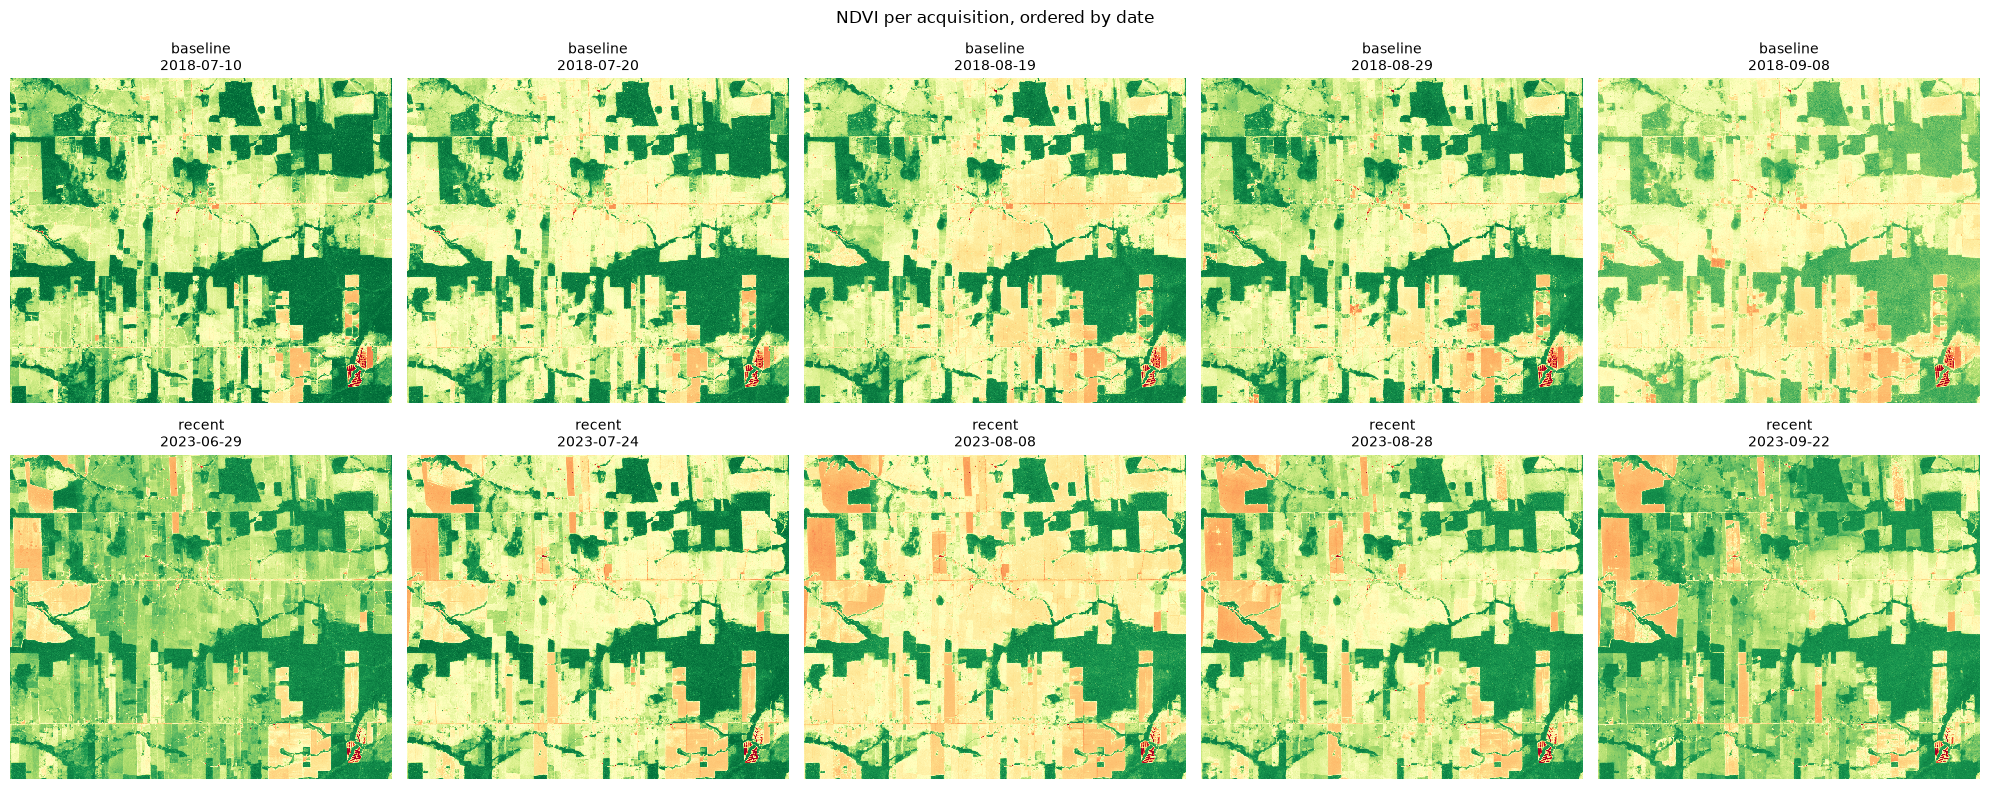

In [28]:
ordered_scenes = sorted(scenes.items(), key=lambda kv: kv[1]["date"])

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, (scene_id, info) in zip(axes, ordered_scenes):
    info["ndvi"].plot(ax=ax, cmap="RdYlGn", vmin=-0.2, vmax=0.9, add_colorbar=False)
    ax.set_title(f"{info['period']}\n{info['date'][:10]}", fontsize=10)
    ax.axis("off")

plt.suptitle("NDVI per acquisition, ordered by date")
plt.tight_layout()
plt.savefig("ndvi_per_acquisition_grid.png", dpi=150)
plt.show()

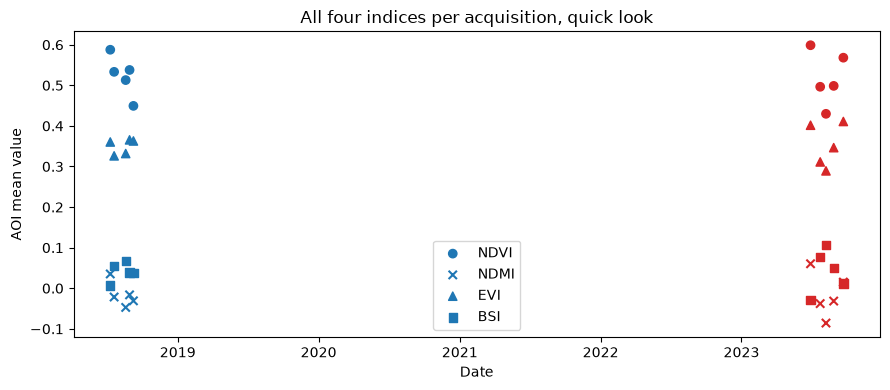

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = summary_df["period"].map({"baseline": "tab:blue", "recent": "tab:red"})
dates = pd.to_datetime(summary_df["date"])

ax.scatter(dates, summary_df["mean_ndvi"], c=colors, marker="o", label="NDVI")
ax.scatter(dates, summary_df["mean_ndmi"], c=colors, marker="x", label="NDMI")
ax.scatter(dates, summary_df["mean_evi"], c=colors, marker="^", label="EVI")
ax.scatter(dates, summary_df["mean_bsi"], c=colors, marker="s", label="BSI")
ax.set_xlabel("Date")
ax.set_ylabel("AOI mean value")
ax.set_title("All four indices per acquisition, quick look")
ax.legend()
plt.tight_layout()
plt.savefig("indices_quick_look.png", dpi=150)
plt.show()

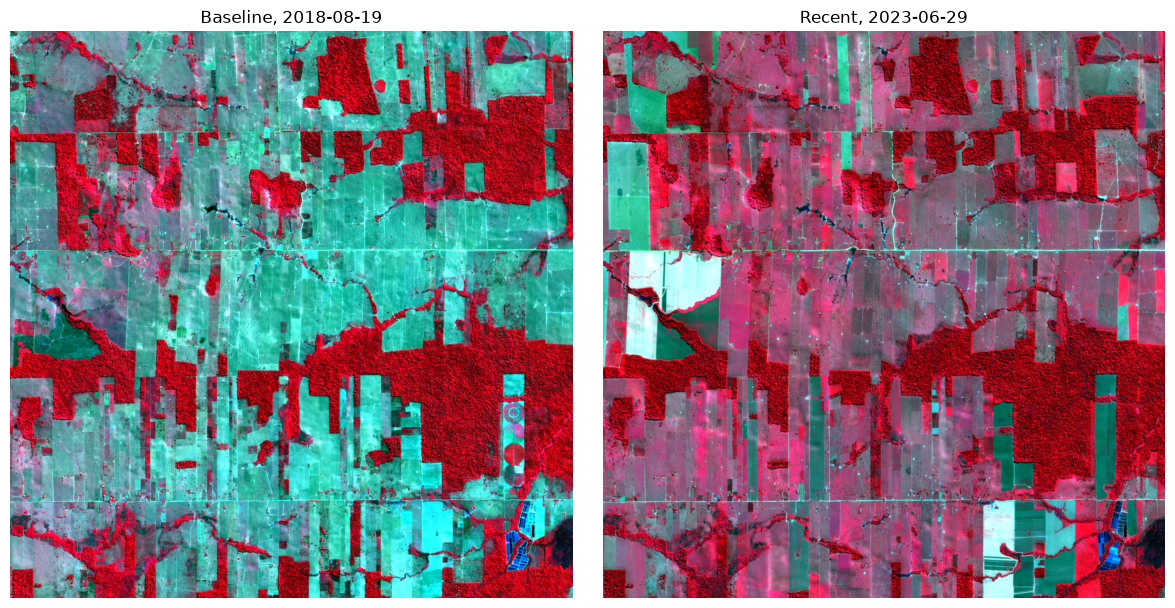

In [32]:
baseline_example = next(info for info in scenes.values() if info["period"] == "baseline")
recent_example = next(info for info in scenes.values() if info["period"] == "recent")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(false_color(baseline_example["clean"]))
axes[0].set_title(f"Baseline, {baseline_example['date'][:10]}")
axes[0].axis("off")
axes[1].imshow(false_color(recent_example["clean"]))
axes[1].set_title(f"Recent, {recent_example['date'][:10]}")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("false_color_comparison.png", dpi=150)
plt.show()

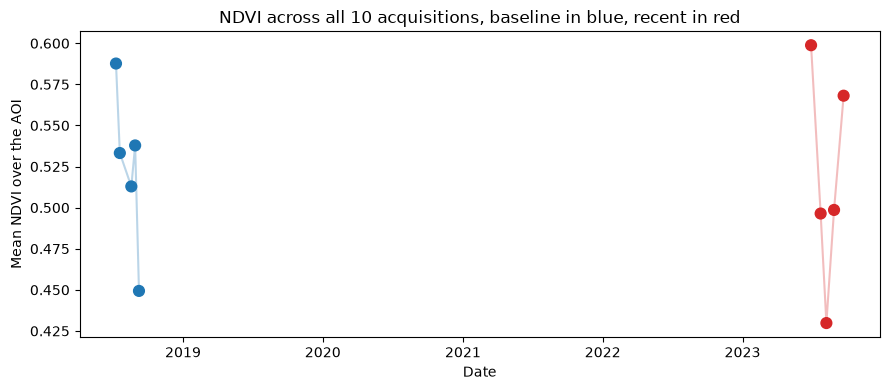

In [33]:
fig, ax = plt.subplots(figsize=(9, 4))

for period_name, color in [("baseline", "tab:blue"), ("recent", "tab:red")]:
    period_rows = summary_df[summary_df["period"] == period_name].sort_values("date")
    period_dates = pd.to_datetime(period_rows["date"])
    ax.plot(period_dates, period_rows["mean_ndvi"], alpha=0.3, color=color)

colors = summary_df["period"].map({"baseline": "tab:blue", "recent": "tab:red"})
dates = pd.to_datetime(summary_df["date"])
ax.scatter(dates, summary_df["mean_ndvi"], c=colors, s=60)

ax.set_xlabel("Date")
ax.set_ylabel("Mean NDVI over the AOI")
ax.set_title("NDVI across all 10 acquisitions, baseline in blue, recent in red")
plt.tight_layout()
plt.savefig("ndvi_time_series.png", dpi=150)
plt.show()

medians and change computed for ndvi, ndmi, evi, bsi
saved ndvi_change.tif, CRS: EPSG:32720 shape: (1108, 1100)


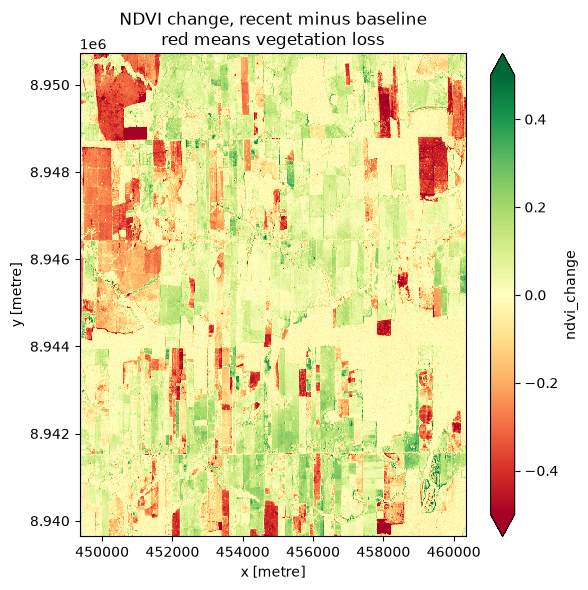

In [41]:
index_names = ["ndvi", "ndmi", "evi", "bsi"]
medians = {}

for index_name in index_names:
    baseline_median = period_median(index_name, "baseline",scenes)
    recent_median = period_median(index_name, "recent",scenes)
    change = (recent_median - baseline_median).rename(f"{index_name}_change")
    change = change.rio.write_crs(baseline_median.rio.crs)
    medians[index_name] = {"baseline": baseline_median, "recent": recent_median, "change": change}

print("medians and change computed for", ", ".join(index_names))

ndvi_change = medians["ndvi"]["change"]
ndvi_change.rio.to_raster(os.path.join("ndvi_change.tif"), driver="COG")
print("saved ndvi_change.tif, CRS:", ndvi_change.rio.crs, "shape:", ndvi_change.shape)

fig, ax = plt.subplots(figsize=(6, 6))
ndvi_change.plot(ax=ax, cmap="RdYlGn", vmin=-0.5, vmax=0.5)
ax.set_title("NDVI change, recent minus baseline\nred means vegetation loss")
plt.tight_layout()
plt.savefig(os.path.join( "ndvi_change_map.png"), dpi=150)
plt.show()

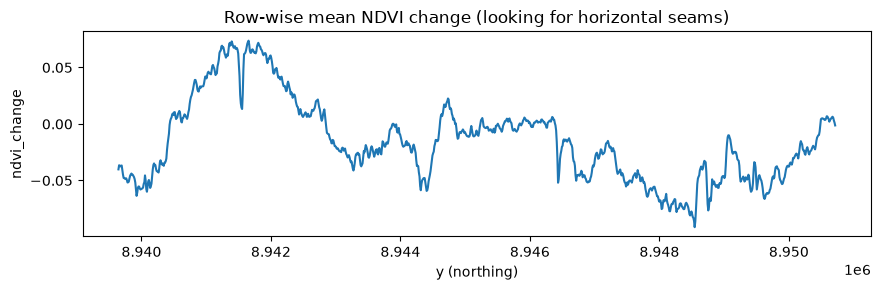

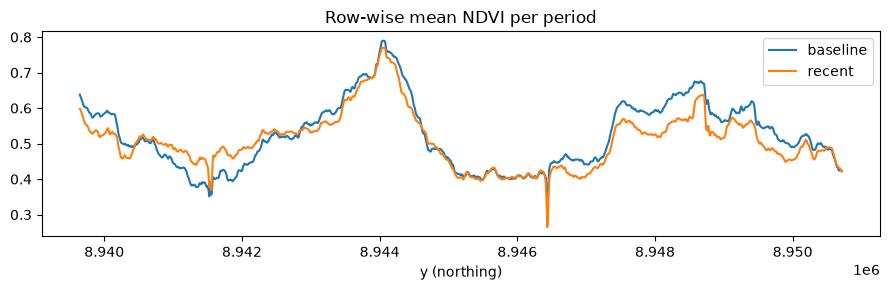

In [42]:
fig, ax = plt.subplots(figsize=(9, 3))
ndvi_change.mean(dim="x", skipna=True).plot(ax=ax)
ax.set_title("Row-wise mean NDVI change (looking for horizontal seams)")
ax.set_xlabel("y (northing)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3))
medians["ndvi"]["baseline"].mean(dim="x", skipna=True).plot(ax=ax, label="baseline")
medians["ndvi"]["recent"].mean(dim="x", skipna=True).plot(ax=ax, label="recent")
ax.set_title("Row-wise mean NDVI per period")
ax.set_xlabel("y (northing)")
ax.legend()
plt.tight_layout()
plt.show()

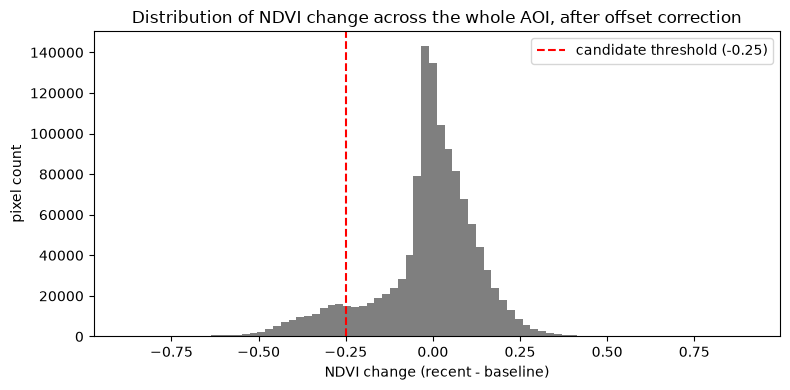

9.3% of all AOI pixels fall below -0.25 NDVI change


In [45]:
change_values = ndvi_change.values
change_values = change_values[np.isfinite(change_values)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(change_values, bins=80, color="tab:gray")
ax.axvline(-0.25, color="red", linestyle="--", label="candidate threshold (-0.25)")
ax.set_xlabel("NDVI change (recent - baseline)")
ax.set_ylabel("pixel count")
ax.set_title("Distribution of NDVI change across the whole AOI, after offset correction")
ax.legend()
plt.tight_layout()
plt.show()

fraction_below = (change_values < -0.25).mean()
print(f"{fraction_below*100:.1f}% of all AOI pixels fall below -0.25 NDVI change")

In [53]:
CHANGE_THRESHOLD = -0.25
MIN_AREA_M2 = 5000

loss_mask = (ndvi_change < CHANGE_THRESHOLD).astype("uint8").values
transform = ndvi_change.rio.transform()

polygons = [shape(geom) for geom, value in raster_to_shapes(loss_mask, mask=loss_mask.astype(bool), transform=transform)]

loss_gdf = gpd.GeoDataFrame(geometry=polygons, crs=ndvi_change.rio.crs)
loss_gdf = loss_gdf.to_crs(loss_gdf.estimate_utm_crs())
loss_gdf["area_m2"] = loss_gdf.geometry.area
loss_gdf = loss_gdf[loss_gdf["area_m2"] >= MIN_AREA_M2].reset_index(drop=True)
loss_gdf = loss_gdf.to_crs(4326)

loss_gdf.to_file(os.path.join( "vegetation_loss.geojson"), driver="GeoJSON")
print(f"{len(loss_gdf)} polygons kept after the minimum area filter")
print(f"total flagged area: {loss_gdf.to_crs(loss_gdf.estimate_utm_crs()).geometry.area.sum() / 10000:.1f} hectares")
loss_gdf.head()


130 polygons kept after the minimum area filter
total flagged area: 1051.3 hectares


,geometry,area_m2
0,"POLYGON ((-63.44432 -9.49256, -63.44432 -9.492...",5100.0
1,"POLYGON ((-63.45772 -9.492, -63.45772 -9.49209...",46400.0
2,"POLYGON ((-63.45143 -9.49201, -63.45143 -9.492...",227500.0
3,"POLYGON ((-63.3923 -9.49416, -63.3923 -9.49425...",48800.0
4,"POLYGON ((-63.44177 -9.49202, -63.44177 -9.492...",83200.0
